# 4장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 폴더: C:\Users\hryug\Desktop\실습\pm\프로덕트 분석
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [6]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [7]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [8]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

In [9]:
# TODO: 테이블별 EDA 요약표를 만드세요.
summary_rows = []

for name, df in data.items():
    dates = pd.concat([df[c] for c in date_columns[name]])
    summary_rows.append({
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "date_min": dates.min().date(),
        "date_max": dates.max().date(),
    })

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

for name, df in data.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n[{name}] 결측치 컬럼")
        print(missing)

,table,rows,cols,missing,duplicate_rows,date_min,date_max
0,accounts,500,10,0,0,2023-01-02,2024-12-31
1,subscriptions,5000,14,4514,0,2023-01-09,2024-12-31
2,feature_usage,25000,8,0,0,2023-01-01,2024-12-31
3,support_tickets,2000,9,825,0,2023-01-02,2024-12-31
4,churn_events,600,9,148,0,2023-01-25,2024-12-31



[subscriptions] 결측치 컬럼
end_date    4514
dtype: int64

[support_tickets] 결측치 컬럼
satisfaction_score    825
dtype: int64

[churn_events] 결측치 컬럼
feedback_text    148
dtype: int64


---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

전체 계정 이탈률: 22.0%

[industry]


,accounts,churn_rate,above_overall
industry,,,
DevTools,113,31.0%,True
FinTech,112,22.3%,True
HealthTech,96,21.9%,False
EdTech,79,16.5%,False
Cybersecurity,100,16.0%,False



[referral_source]


,accounts,churn_rate,above_overall
referral_source,,,
event,96,30.2%,True
other,103,24.3%,True
ads,98,23.5%,True
organic,114,17.5%,False
partner,89,14.6%,False



[is_trial]


,accounts,churn_rate,above_overall
is_trial,,,
True,97,25.8%,True
False,403,21.1%,False


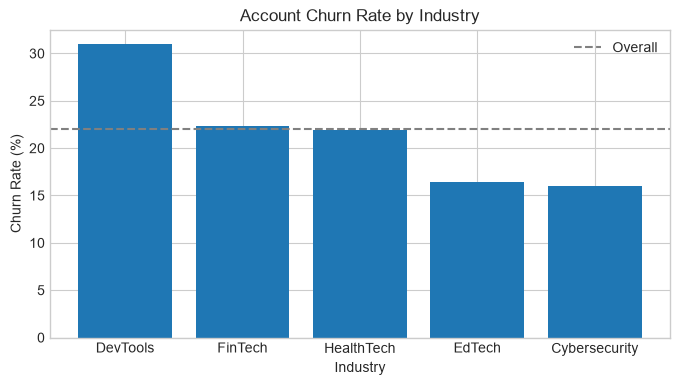

In [13]:
# TODO: 전체 및 세그먼트별 이탈률을 계산하세요.
overall_churn_rate = accounts["churn_flag"].mean()
print(f"전체 계정 이탈률: {overall_churn_rate:.1%}")

segment_results = {}
for column in ["industry", "referral_source", "is_trial"]:
    result = (
        accounts.groupby(column)["churn_flag"]
        .agg(accounts="size", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
    )
    result["above_overall"] = (result["accounts"] >= 20) & (result["churn_rate"] > overall_churn_rate)
    segment_results[column] = result
    print(f"\n[{column}]")
    display(result.assign(churn_rate=result["churn_rate"].map("{:.1%}".format)))

# TODO: 산업별 이탈률 그래프를 그리세요.
industry = segment_results["industry"]
plt.figure(figsize=(8, 4))
plt.bar(industry.index, industry["churn_rate"] * 100)
plt.axhline(overall_churn_rate * 100, color="gray", linestyle="--", label="Overall")
plt.xlabel("Industry")
plt.ylabel("Churn Rate (%)")
plt.title("Account Churn Rate by Industry")
plt.legend()
plt.show()

### 필수 2 서술 답안

- 발견한 핵심 패턴:
- 문제 정의:
- 현재 지표:
- 목표 지표:
- 목표 지표가 적절한 이유:

---

## 과제 1 — 이탈 원인 가설과 검증 계획 세우기

필수 2에서 정의한 문제를 바탕으로 초기 가설 3개를 작성하세요.

- 적어도 2개는 현재 제공된 데이터로 검증 가능해야 합니다.
- 각 가설에 `필요한 테이블·컬럼`, `확인할 비교 또는 지표`, `우선순위`를 적으세요.
- 가장 먼저 검증할 가설 1개를 고르고 이유를 설명하세요.
- 2강 분석 → 3강 실험 → 4강 제안이 처음 문제와 어떻게 연결되는지 한 문장씩 작성하세요.

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---:|---|---|---|
| 1 | 이탈률이 높은 산업군은 제품 사용이 적어 이탈이 높을 수 있다. | accounts의 account_id, industry, churn_flag / subscriptions의 account_id, subscription_id / feature_usage의 subscription_id, usage_count | 산업군별 기능 사용 수준과 이탈률을 비교한다. |
| 2 | 문의가 많거나 처리 경험이 좋지 않은 계정은 이탈률이 높을 수 있다. | support_tickets의 문의·처리 정보 / accounts의 account_id, churn_flag / support_tickets의 account_id, resolution_time_hours, satisfaction_score | 이탈 계정과 비이탈 계정의 문의 횟수와 처리 경험을 비교한다. |
| 3 | 특정 이탈 사유가 일부 고객군에 집중되어 있을 수 있다. | churn_events의 account_id, reason_code / accounts의 account_id, industry, referral_source | 이탈 사유의 빈도를 고객 특성별로 비교한다. |

- 1번 가설을 먼저 검증한다. DevTools의 이탈률이 31.0%로 전체 22.0%보다 높고 현재 데이터로 기능 사용 차이를 확인할 수 있기 때문이다.

### 프로젝트 연결

- 2강 분석: 이탈률이 높은 고객군의 행동과 특성을 비교해 원인 가설을 구체화한다.
- 3강 실험: 개선안을 적용한 그룹과 기존 그룹의 이탈 관련 지표를 비교한다.
- 4강 제안: 분석과 실험 결과를 바탕으로 실제 개선 방향을 제안한다.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?
- 어떤 통계적·분석적 방법을 적용했는가?
- 무엇을 근거로 결론을 내렸는가?